In [27]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

In [28]:
import time
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

## 1) Load Data + Split

In [29]:
df = pd.read_csv("nigerian_loan_default.csv")

TARGET = "defaulted"

numeric_features = [
    "age",
    "monthly_income_ngn",
    "loan_amount_ngn",
    "tenure_months",
    "interest_rate",
    "prior_defaults",
    "credit_score",
    "has_bank_account",
]

categorical_features = ["state", "employment_type"]

X = df[numeric_features + categorical_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Class balance (train):")
print(y_train.value_counts(normalize=True).rename("rate"))

Train: (450, 10) Test: (150, 10)
Class balance (train):
defaulted
0    0.588889
1    0.411111
Name: rate, dtype: float64


## 2) Shared Preprocessing
- Scale numeric features (important for KNN/SVM)
- One-hot encode categorical features

In [30]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ]
)

## 3) Define Models
We keep preprocessing constant and swap only the classifier.

In [31]:
models = {
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "SVM RBF": SVC(kernel="rbf", C=2.0, gamma="scale", probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=1000,
        random_state=42,
    ),
}


def train_eval(name, clf):
    pipe = Pipeline(steps=[("preprocess", preprocess), ("clf", clf)])

    start = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start

    pred = pipe.predict(X_test)

    # Some models provide predict_proba; SVC uses probability=True
    proba = None
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X_test)[:, 1]

    metrics = {
        "model": name,
        "fit_time_s": fit_time,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba) if proba is not None else np.nan,
    }

    return pipe, pred, metrics


results = []
trained = {}

for name, clf in models.items():
    pipe, pred, m = train_eval(name, clf)
    trained[name] = (pipe, pred)
    results.append(m)

results_df = pd.DataFrame(results).sort_values(by="f1", ascending=False)
results_df

,model,fit_time_s,accuracy,precision,recall,f1,roc_auc
1,SVM RBF,0.037553,0.646667,0.574074,0.508197,0.539130,0.651870
0,KNN (k=7),0.006273,0.653333,0.588235,0.491803,0.535714,0.660158
5,Neural Network,0.687877,0.606667,0.515152,0.557377,0.535433,0.614662
3,Random Forest,0.664004,0.653333,0.609756,0.409836,0.490196,0.661079
4,Gradient Boosting,0.113765,0.580000,0.481481,0.426230,0.452174,0.597348
2,Decision Tree,0.008103,0.620000,0.555556,0.327869,0.412371,0.603887


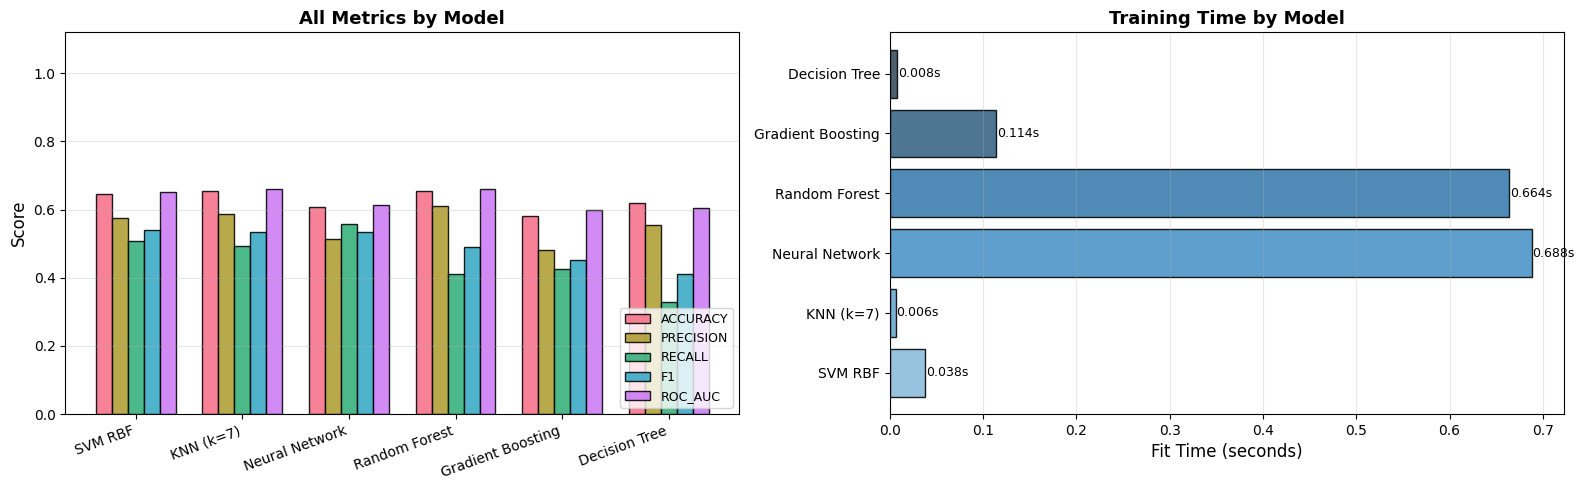

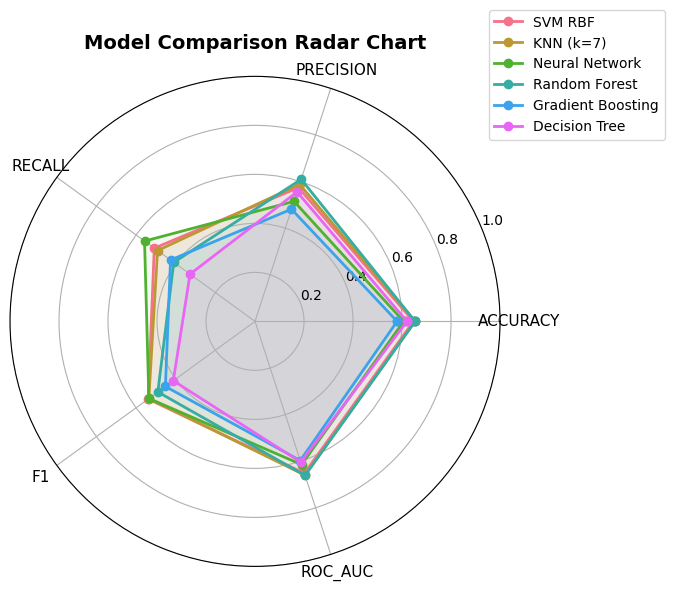

In [32]:
# ── Metrics comparison: grouped bar chart ──────────────────────────────────
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_df = results_df.set_index("model")[metric_cols]

x = np.arange(len(plot_df))
width = 0.15
colors = sns.color_palette("husl", len(metric_cols))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar
for i, (col, color) in enumerate(zip(metric_cols, colors)):
    bars = ax1.bar(x + i * width, plot_df[col], width, label=col.upper(),
                   color=color, edgecolor='black', alpha=0.88)

ax1.set_xticks(x + width * 2)
ax1.set_xticklabels(plot_df.index, rotation=20, ha='right', fontsize=10)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("All Metrics by Model", fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.12)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')

# Right: fit time bar
fit_times = results_df.set_index("model")["fit_time_s"]
colors_t = sns.color_palette("Blues_d", len(fit_times))
ax2.barh(fit_times.index, fit_times.values, color=colors_t, edgecolor='black', alpha=0.88)
for i, v in enumerate(fit_times.values):
    ax2.text(v + 0.001, i, f'{v:.3f}s', va='center', fontsize=9)
ax2.set_xlabel("Fit Time (seconds)", fontsize=12)
ax2.set_title("Training Time by Model", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ── Radar / spider chart ───────────────────────────────────────────────────
radar_metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]
N = len(radar_metrics)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
palette = sns.color_palette("husl", len(plot_df))

for (model_name, row), color in zip(plot_df.iterrows(), palette):
    values = row[radar_metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([m.upper() for m in radar_metrics], fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Model Comparison Radar Chart", fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout()
plt.show()

## 4) Pick the Best Model and Inspect Errors
We’ll look at confusion matrix + classification report for the top model.

In [33]:
best_name = results_df.iloc[0]["model"]
best_pipe, best_pred = trained[best_name]

print("Best model:", best_name)
print("\nConfusion matrix:")
print(confusion_matrix(y_test, best_pred))
print("\nClassification report:")
print(classification_report(y_test, best_pred, zero_division=0))

Best model: SVM RBF

Confusion matrix:
[[66 23]
 [30 31]]

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.74      0.71        89
           1       0.57      0.51      0.54        61

    accuracy                           0.65       150
   macro avg       0.63      0.62      0.63       150
weighted avg       0.64      0.65      0.64       150



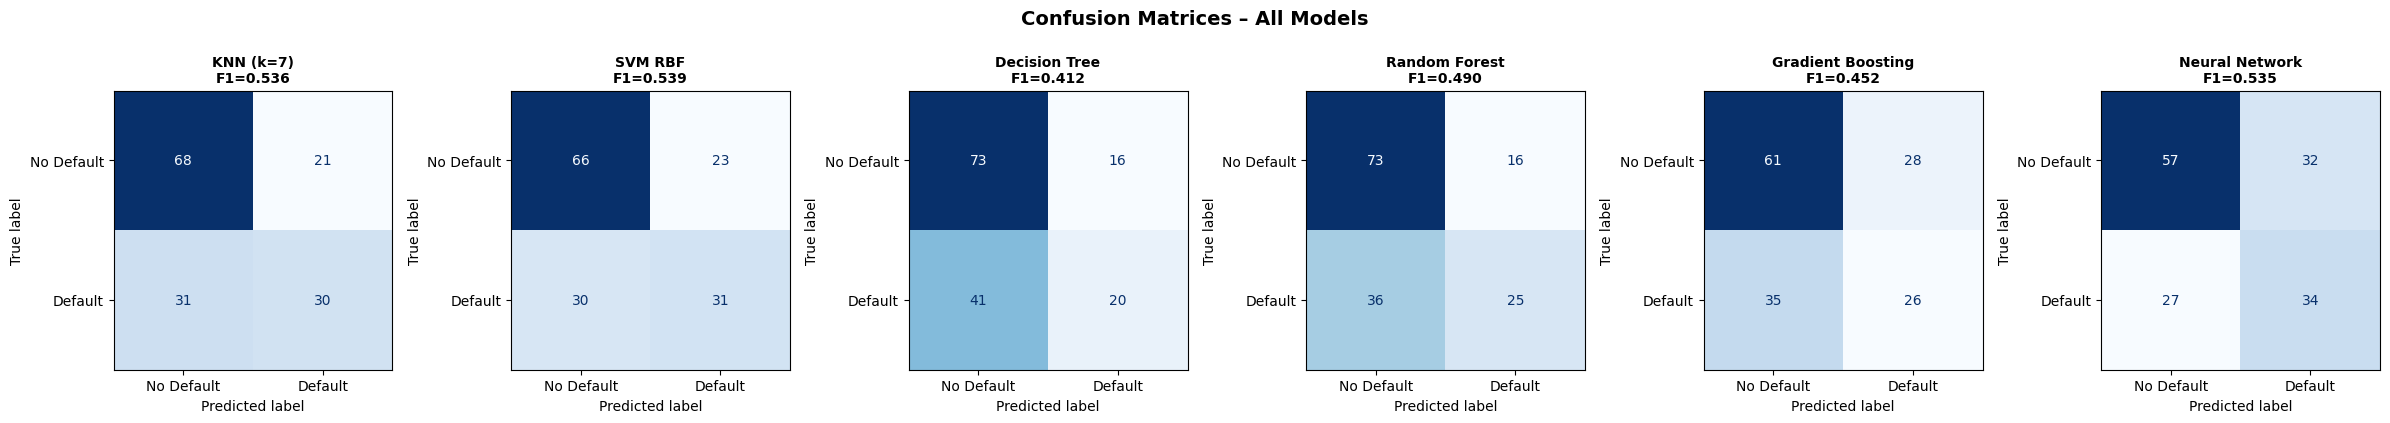

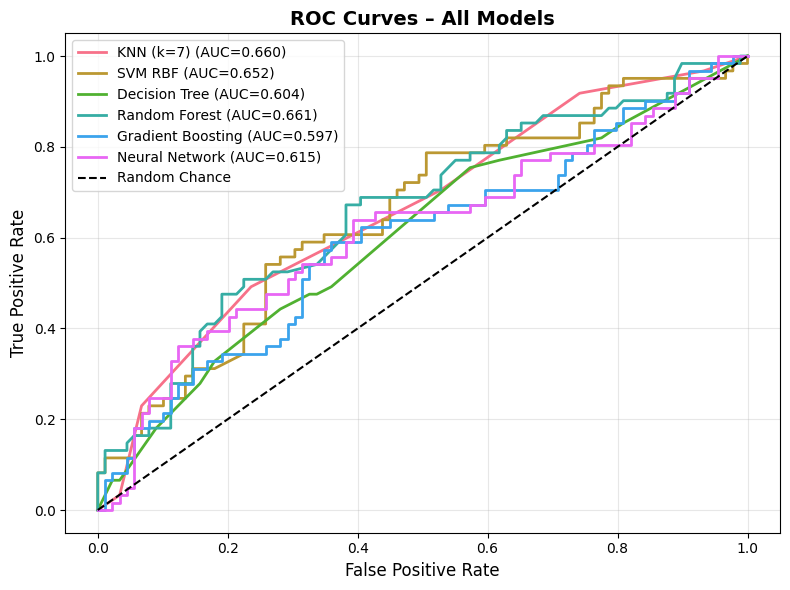

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Side-by-side confusion matrices for all 5 models ───────────────────────
n_models = len(trained)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
model_names = list(trained.keys())

for ax, name in zip(axes, model_names):
    pipe, pred = trained[name]
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Default", "Default"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    f1 = results_df.loc[results_df["model"] == name, "f1"].values[0]
    ax.set_title(f"{name}\nF1={f1:.3f}", fontsize=10, fontweight='bold')

fig.suptitle("Confusion Matrices – All Models", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── ROC curves overlay ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("husl", n_models)

for (name, (pipe, _)), color in zip(trained.items(), palette):
    if hasattr(pipe, "predict_proba"):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe, "decision_function"):
        y_prob = pipe.decision_function(X_test)
    else:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves – All Models", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5) Discussion Prompts
- Which model is fastest to train?
- Which has the best F1 (or ROC-AUC)?
- Which is easiest to explain to stakeholders?
- If your dataset is much larger, which model would scale best?

## Mini Exercise (10 mins)
1) Tune KNN: try `k` in [3, 5, 7, 11, 15] and track F1.
2) Tune DecisionTree: try `max_depth` in [2, 3, 4, 5, 7, 10].
3) For SVM: try changing `C` to 0.5 and 5.0.

Record what changes bias vs variance.

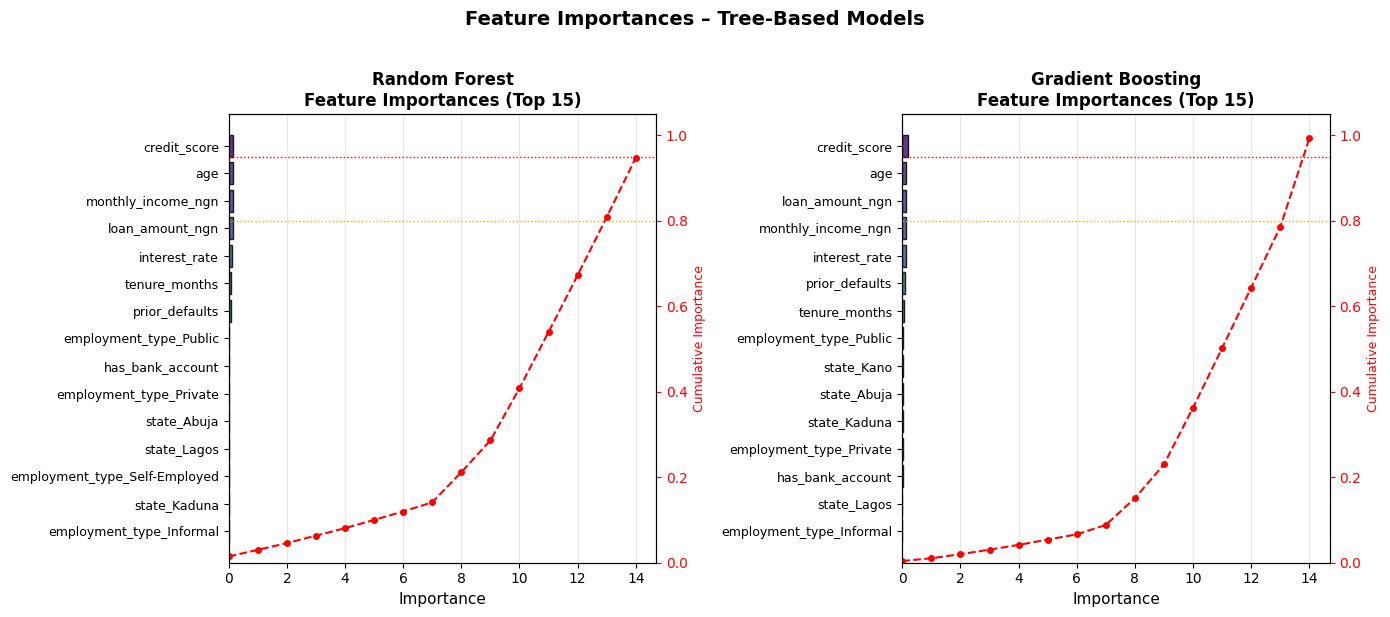

In [35]:
# ── Feature importances: Random Forest & Gradient Boosting ─────────────────
tree_models = {k: v for k, v in trained.items()
               if k in ("Random Forest", "Gradient Boosting")}

if not tree_models:
    print("No tree-based models found.")
else:
    # Recover feature names from the preprocessing pipeline
    _sample_pipe = trained[list(tree_models.keys())[0]][0]
    _ct = _sample_pipe.named_steps['preprocess']
    try:
        _num_cols = _ct.transformers_[0][2]          # numeric column names
        _ohe      = _ct.transformers_[1][1].named_steps['ohe']
        _cat_cols = _ct.transformers_[1][2]
        _cat_names = _ohe.get_feature_names_out(_cat_cols)
        feature_names = list(_num_cols) + list(_cat_names)
    except Exception:
        _clf_tmp = _sample_pipe.named_steps['clf']
        feature_names = [f"f{i}" for i in range(_clf_tmp.n_features_in_)]

    n_tm = len(tree_models)
    fig, axes = plt.subplots(1, n_tm, figsize=(10 * n_tm // n_tm + 4, 6))
    if n_tm == 1:
        axes = [axes]

    for ax, (name, (pipe, _)) in zip(axes, tree_models.items()):
        clf = pipe.named_steps['clf']
        importances = clf.feature_importances_
        # match length
        fn = feature_names[:len(importances)] if len(feature_names) >= len(importances) \
             else [f"f{i}" for i in range(len(importances))]
        idx = np.argsort(importances)[::-1]
        top_n = min(15, len(importances))
        colors = sns.color_palette("viridis", top_n)

        ax.barh(range(top_n), importances[idx[:top_n]][::-1],
                color=colors[::-1], edgecolor='black', alpha=0.85)
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([fn[i] for i in idx[:top_n]][::-1], fontsize=9)
        ax.set_xlabel("Importance", fontsize=11)
        ax.set_title(f"{name}\nFeature Importances (Top {top_n})",
                     fontsize=12, fontweight='bold')
        ax.grid(True, axis='x', alpha=0.3)

        # cumulative curve on twin axis
        ax2 = ax.twinx()
        cum = np.cumsum(importances[idx[:top_n]][::-1]) / importances.sum()
        ax2.plot(range(top_n), cum, 'r--o', ms=4, lw=1.5, label='Cumulative')
        ax2.axhline(0.8, color='orange', lw=1, ls=':')
        ax2.axhline(0.95, color='red', lw=1, ls=':')
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel("Cumulative Importance", fontsize=9, color='red')
        ax2.tick_params(axis='y', colors='red')

    plt.suptitle("Feature Importances – Tree-Based Models",
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 1) Load Data + Split

In [23]:
df = pd.read_csv("nigerian_loan_default.csv")

TARGET = "defaulted"

numeric_features = [
    "age",
    "monthly_income_ngn",
    "loan_amount_ngn",
    "tenure_months",
    "interest_rate",
    "prior_defaults",
    "credit_score",
    "has_bank_account",
]

categorical_features = ["state", "employment_type"]

X = df[numeric_features + categorical_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Class balance (train):")
print(y_train.value_counts(normalize=True).rename("rate"))

Train: (60, 10) Test: (20, 10)
Class balance (train):
defaulted
0    0.65
1    0.35
Name: rate, dtype: float64


## 2) Shared Preprocessing
- Scale numeric features (important for KNN/SVM)
- One-hot encode categorical features

In [24]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ]
)

## 3) Define Models
We keep preprocessing constant and swap only the classifier.